# EEGNet Preprocessing + BERT Retrieval — Laslo Tudor Alexandru (P1)
## Saptamana 14 — Proiect EEG-to-Text

**Branch:** `Sapt_14_Laslo` | **PR #2**

Pipeline: ZuCo1 SR -> preprocesare -> EEGNet (128d) -> proiectie **InfoNCE** -> BERT retrieval (200 cuvinte)

**Update:** Proiectia foloseste InfoNCE contrastive loss + full vocabulary negatives (in loc de MSE).

## 0. Setup director de lucru

In [22]:
import os
from pathlib import Path
search = Path.cwd()
for _ in range(6):
    if (search / 'benchmark_config.json').exists():
        os.chdir(search); break
    search = search.parent
print('Working directory:', os.getcwd())
assert Path('benchmark_config.json').exists()
print('benchmark_config.json: OK')

Working directory: C:\Users\alexl\School\AI\eeg_ai_project\EEG-text
benchmark_config.json: OK


## 1. Incarcare date
Incarcam cele 5 fisiere per-subiect din folderul ZuCo1 SR si `benchmark_config.json`.
rawEEG shape (4, 105, 120) -> concatenat -> (105, 480), pad la 500 samples.

In [23]:
import scipy.io as sio, numpy as np, json, glob
EEG_DIR = r'C:\Users\alexl\School\AI\eeg_ai_project\project\data\ZuCo1\task1_SR'
mat_files = sorted(glob.glob(os.path.join(EEG_DIR, 'results*_SR.mat')))
print(f'Fisiere gasite: {len(mat_files)}')
for f in mat_files: print(' ', os.path.basename(f))
with open('benchmark_config.json') as f: config = json.load(f)
print(f"Vocabular: {len(config['vocabulary'])} cuvinte")
print(f"Split: train={len(config['train_words'])}, val={len(config['val_words'])}, test={len(config['test_words'])}")

Fisiere gasite: 5
  resultsZAB_SR.mat
  resultsZDM_SR.mat
  resultsZDN_SR.mat
  resultsZJS_SR.mat
  resultsZKB_SR.mat
Vocabular: 200 cuvinte
Split: train=140, val=30, test=30


## 2. Extragere epoci EEG per cuvant
rawEEG (4, 105, 120) -> (105, 480) -> pad/crop la 500

In [24]:
VOCABULARY=set(config['vocabulary']); TRAIN_WORDS=set(config['train_words'])
VAL_WORDS=set(config['val_words']); TEST_WORDS=set(config['test_words'])
N_CH=config['eeg']['n_channels']; FS=config['eeg']['sampling_rate_hz']
S_MS=config['eeg']['epoch_window_ms'][0]; E_MS=config['eeg']['epoch_window_ms'][1]
T_S=int((E_MS-S_MS)/1000*FS); BL_S=int(abs(S_MS)/1000*FS)
epochs_list,labels_list,split_list=[],[],[]
skip_v,skip_s,skip_e=0,0,0
for mat_path in mat_files:
    subj=os.path.basename(mat_path).replace('results','').replace('_SR.mat','')
    try: mat=sio.loadmat(mat_path,simplify_cells=True)
    except: continue
    sd=mat['sentenceData']; print(f'{subj}: {len(sd)} propozitii')
    for sent in sd:
        try: words=sent['word']
        except: continue
        if not hasattr(words,'__len__'): words=[words]
        for wo in words:
            try: wt=str(wo['content']).lower().strip(); re=wo['rawEEG']
            except: skip_e+=1; continue
            if wt not in VOCABULARY: skip_v+=1; continue
            if not hasattr(re,'ndim'): re=np.array(re)
            if re.ndim==3 and re.shape[1]==N_CH: ep=re.transpose(1,0,2).reshape(N_CH,-1)
            elif re.ndim==2 and re.shape[0]==N_CH: ep=re
            else: skip_s+=1; continue
            T=ep.shape[1]
            if T<T_S: ep=np.hstack([ep,np.zeros((N_CH,T_S-T))])
            else: ep=ep[:,:T_S]
            if wt in TRAIN_WORDS: sp='train'
            elif wt in VAL_WORDS: sp='val'
            elif wt in TEST_WORDS: sp='test'
            else: continue
            epochs_list.append(ep.astype(np.float32)); labels_list.append(wt); split_list.append(sp)
print(f'Total: {len(epochs_list)}, skip_vocab:{skip_v}, skip_shape:{skip_s}, skip_err:{skip_e}')

ZAB: 400 propozitii
ZDM: 400 propozitii
ZDN: 400 propozitii
ZJS: 400 propozitii
ZKB: 400 propozitii
Total: 1136, skip_vocab:31386, skip_shape:1271, skip_err:117


## 3. Preprocesare EEG
Bandpass 0.5-40Hz | Baseline correction | Artifact rejection (>100uV) | Z-score

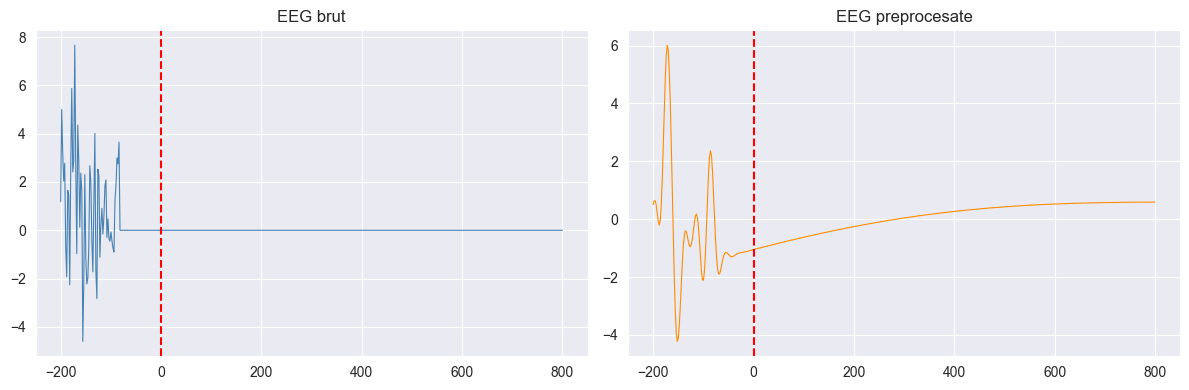

Dupa preprocesare: (1136, 105, 500), respinse: 0
Salvate: data/X_preprocessed.npy, y_labels.npy, splits.npy


In [25]:
import mne; from mne import create_info; import matplotlib.pyplot as plt
def preprocess_epoch(eeg,fs=500,l=0.5,h=40.,bl=100,th=100.):
    info=create_info(ch_names=eeg.shape[0],sfreq=fs,ch_types='eeg')
    raw=mne.io.RawArray(eeg,info,verbose=False)
    raw.filter(l_freq=l,h_freq=h,method='iir',iir_params={'order':4,'ftype':'butter'},verbose=False)
    f=raw.get_data(); c=f-f[:,:bl].mean(axis=1,keepdims=True)
    if np.any(np.abs(c)>th): return None
    return ((c-c.mean(axis=1,keepdims=True))/(c.std(axis=1,keepdims=True)+1e-8)).astype(np.float32)
times=np.linspace(S_MS,E_MS,T_S)
if epochs_list:
    fig,ax=plt.subplots(1,2,figsize=(12,4))
    ax[0].plot(times,epochs_list[0][10],color='steelblue',lw=0.8); ax[0].axvline(0,color='red',ls='--'); ax[0].set_title('EEG brut')
    p=preprocess_epoch(epochs_list[0])
    if p is not None: ax[1].plot(times,p[10],color='darkorange',lw=0.8); ax[1].axvline(0,color='red',ls='--'); ax[1].set_title('EEG preprocesate')
    plt.tight_layout(); plt.savefig('notebooks/Laslo/erp_before_after.png',dpi=150,bbox_inches='tight'); plt.show()
pe,pl,ps,rej=[],[],[],0
for eeg,lab,sp in zip(epochs_list,labels_list,split_list):
    r=preprocess_epoch(eeg)
    if r is not None: pe.append(r); pl.append(lab); ps.append(sp)
    else: rej+=1
X=np.array(pe); y=np.array(pl); splits=np.array(ps)
print(f'Dupa preprocesare: {X.shape}, respinse: {rej}')
np.save('data/X_preprocessed.npy',X); np.save('data/y_labels.npy',y); np.save('data/splits.npy',splits)
print('Salvate: data/X_preprocessed.npy, y_labels.npy, splits.npy')

## 4. Mapare label -> POS + split

In [26]:
from collections import Counter
vocab_list=config['vocabulary']; pos_map=config['vocabulary_pos']
os.makedirs('app/models',exist_ok=True)
with open('app/models/vocab_index.json','w') as f: json.dump({str(i):w for i,w in enumerate(vocab_list)},f,indent=2)
print('Salvat: app/models/vocab_index.json')
pos_u=sorted(set(pos_map.values())); p2i={p:i for i,p in enumerate(pos_u)}; print('POS:',p2i)
y_pos=np.array([p2i[pos_map[l]] for l in pl])
ti=np.where(splits=='train')[0]; vi=np.where(splits=='val')[0]; tei=np.where(splits=='test')[0]
X_tr,y_tr=X[ti],y_pos[ti]; X_v,y_v=X[vi],y_pos[vi]; X_te,y_te=X[tei],y_pos[tei]
print(f'X_train:{X_tr.shape}, X_val:{X_v.shape}, X_test:{X_te.shape}')

Salvat: app/models/vocab_index.json
POS: {'ADJ': 0, 'ADP': 1, 'ADV': 2, 'INTJ': 3, 'NOUN': 4, 'NUM': 5, 'PRON': 6, 'PROPN': 7, 'SCONJ': 8, 'VERB': 9}
X_train:(922, 105, 500), X_val:(106, 105, 500), X_test:(108, 105, 500)


## 5. EEGNet (F1=8, D=2, F2=16, kern=64) + embedding 128 dim

In [27]:
import torch, torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
device=torch.device('cuda' if torch.cuda.is_available() else 'cpu'); print('Device:',device)
N_CLS=len(pos_u)
class EEGNetWithEmbedding(nn.Module):
    def __init__(self,nc=105,nt=500,F1=8,D=2,F2=16,kl=64,ed=128,nc2=N_CLS,dp=0.5):
        super().__init__()
        self.block1=nn.Sequential(nn.Conv2d(1,F1,(1,kl),padding=(0,kl//2),bias=False),nn.BatchNorm2d(F1),nn.Conv2d(F1,F1*D,(nc,1),groups=F1,bias=False),nn.BatchNorm2d(F1*D),nn.ELU(),nn.AvgPool2d((1,4)),nn.Dropout(dp))
        self.block2=nn.Sequential(nn.Conv2d(F1*D,F1*D,(1,16),padding=(0,8),groups=F1*D,bias=False),nn.Conv2d(F1*D,F2,(1,1),bias=False),nn.BatchNorm2d(F2),nn.ELU(),nn.AvgPool2d((1,8)),nn.Dropout(dp))
        with torch.no_grad(): fd=self.block2(self.block1(torch.zeros(1,1,nc,nt))).flatten(1).shape[-1]
        print(f'Flatten dim: {fd}')
        self.emb=nn.Linear(fd,ed); self.drop=nn.Dropout(dp); self.cls=nn.Linear(ed,nc2)
    def forward(self,x,return_embedding=False):
        f=self.block2(self.block1(x)).flatten(1); e=self.emb(f)
        return e if return_embedding else self.cls(self.drop(e))
model=EEGNetWithEmbedding().to(device)
print(f'Parametri: {sum(p.numel() for p in model.parameters()):,}')

Device: cpu
Flatten dim: 240
Parametri: 34,922


In [28]:
trl=DataLoader(TensorDataset(torch.tensor(X_tr[:,np.newaxis,:,:],dtype=torch.float32),torch.tensor(y_tr,dtype=torch.long)),batch_size=32,shuffle=True,drop_last=True)
vl_=DataLoader(TensorDataset(torch.tensor(X_v[:,np.newaxis,:,:],dtype=torch.float32),torch.tensor(y_v,dtype=torch.long)),batch_size=32)
opt=torch.optim.Adam(model.parameters(),lr=1e-3,weight_decay=1e-4)
sch=torch.optim.lr_scheduler.StepLR(opt,step_size=10,gamma=0.5)
crit=nn.CrossEntropyLoss(); NE=30; bva=0.; tlos,vaccs=[],[]
for ep in range(NE):
    model.train(); tl,tc,tt=0,0,0
    for xb,yb in trl:
        xb,yb=xb.to(device),yb.to(device); opt.zero_grad()
        lg=model(xb); lo=crit(lg,yb); lo.backward(); opt.step()
        tl+=lo.item()*xb.size(0); tc+=(lg.argmax(1)==yb).sum().item(); tt+=xb.size(0)
    model.eval(); vc,vt=0,0
    with torch.no_grad():
        for xb,yb in vl_:
            xb,yb=xb.to(device),yb.to(device); vc+=(model(xb).argmax(1)==yb).sum().item(); vt+=xb.size(0)
    el=tl/max(tt,1); va=vc/max(vt,1); tlos.append(el); vaccs.append(va); sch.step()
    if (ep+1)%5==0 or va>bva: print(f'Ep {ep+1:02d}/{NE} | Loss:{el:.4f} | ValAcc:{va:.3f}')
    if va>bva: bva=va; torch.save(model.state_dict(),'app/models/eegnet_model.pt'); print(f'  -> salvat val={va:.3f}')
print('Best val acc:',round(bva,3))

Ep 01/30 | Loss:2.0483 | ValAcc:0.453
  -> salvat val=0.453
Ep 05/30 | Loss:1.8052 | ValAcc:0.443
Ep 10/30 | Loss:1.7717 | ValAcc:0.434
Ep 15/30 | Loss:1.7295 | ValAcc:0.415
Ep 20/30 | Loss:1.7298 | ValAcc:0.415
Ep 25/30 | Loss:1.6987 | ValAcc:0.415
Ep 30/30 | Loss:1.6998 | ValAcc:0.406
Best val acc: 0.453


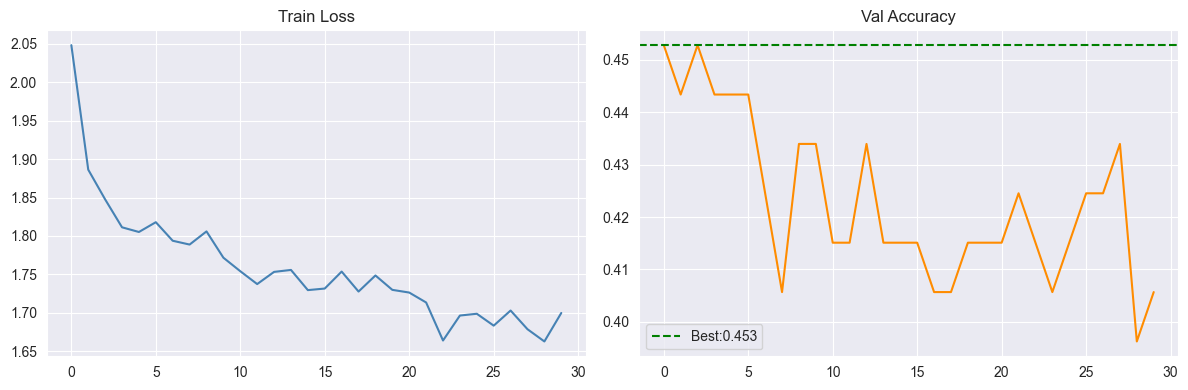

In [29]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].plot(tlos,color='steelblue'); axes[0].set_title('Train Loss')
axes[1].plot(vaccs,color='darkorange'); axes[1].axhline(bva,color='green',ls='--',label=f'Best:{bva:.3f}')
axes[1].set_title('Val Accuracy'); axes[1].legend()
plt.tight_layout(); plt.savefig('notebooks/Laslo/loss_curves.png',dpi=150,bbox_inches='tight'); plt.show()

## 6. BERT embeddings (200 cuvinte, 768 dim)

In [30]:
from transformers import BertTokenizer, BertModel
tok=BertTokenizer.from_pretrained('bert-base-uncased')
bm=BertModel.from_pretrained('bert-base-uncased').to(device); bm.eval()
bert_emb=np.zeros((len(vocab_list),768),dtype=np.float32)
with torch.no_grad():
    for i,w in enumerate(vocab_list):
        inp=tok(w,return_tensors='pt').to(device); out=bm(**inp)
        bert_emb[i]=out.last_hidden_state[:,0,:].squeeze().cpu().numpy()
print('BERT shape:',bert_emb.shape)
np.save('app/models/bert_embeddings.npy',bert_emb); print('Salvat: app/models/bert_embeddings.npy')

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BERT shape: (200, 768)
Salvat: app/models/bert_embeddings.npy


## 7. Proiectie liniara EEG (128) -> BERT (768) — InfoNCE Loss

**De ce InfoNCE in loc de MSE?**
MSE pe embeddings normalizate converge spre un punct fix — returna mereu 'story','movie' etc.
(Top-5 ≈ Top-1 = 14.8%). InfoNCE forteaza discriminarea:

```
logits = normalize(EEG_proj) @ normalize(BERT_all).T / temperature  # (B, 200)
loss   = cross_entropy(logits, target_word_idx)
```
Cuvantul corect trebuie sa bata simultan toate celelalte 199 cuvinte din vocabular.

In [31]:
import torch.nn.functional as F
model.eval(); model.load_state_dict(torch.load('app/models/eegnet_model.pt',map_location=device))
def get_emb(Xn,bs=32):
    out=[]; Xt=torch.tensor(Xn[:,np.newaxis,:,:],dtype=torch.float32)
    with torch.no_grad():
        for i in range(0,len(Xt),bs): out.append(model(Xt[i:i+bs].to(device),return_embedding=True).cpu().numpy())
    return np.vstack(out)
ee_tr=get_emb(X_tr); ee_v=get_emb(X_v); ee_te=get_emb(X_te)
print(f'EEG emb: train={ee_tr.shape}, val={ee_v.shape}, test={ee_te.shape}')

EEG emb: train=(922, 128), val=(106, 128), test=(108, 128)


In [32]:
w2i={w:i for i,w in enumerate(vocab_list)}
y_tr_vi=np.array([w2i[l] for l in y[ti]]); y_v_vi=np.array([w2i[l] for l in y[vi]])
def infonce(eeg_proj,tgt_idx,bert_all,temp=0.07):
    en=F.normalize(eeg_proj,dim=1); bn=F.normalize(bert_all,dim=1)
    return F.cross_entropy(en@bn.T/temp, tgt_idx)
bert_t=torch.tensor(bert_emb,dtype=torch.float32).to(device)
proj=nn.Linear(128,768).to(device)
po=torch.optim.AdamW(proj.parameters(),lr=3e-4,weight_decay=1e-4)
sp=torch.optim.lr_scheduler.CosineAnnealingLR(po,T_max=50); TEMP=0.07
prl=DataLoader(TensorDataset(torch.tensor(ee_tr,dtype=torch.float32),torch.tensor(y_tr_vi,dtype=torch.long)),batch_size=64,shuffle=True)
ev2=torch.tensor(ee_v,dtype=torch.float32).to(device); yv2=torch.tensor(y_v_vi,dtype=torch.long).to(device)
bpl=float('inf'); ptl2,pvl2=[],[]
for ep in range(50):
    proj.train(); tl,n=0.,0
    for xb,yb in prl:
        xb,yb=xb.to(device),yb.to(device); po.zero_grad()
        lo=infonce(proj(xb),yb,bert_t,TEMP); lo.backward(); po.step()
        tl+=lo.item()*xb.size(0); n+=xb.size(0)
    sp.step(); proj.eval()
    with torch.no_grad(): vl=infonce(proj(ev2),yv2,bert_t,TEMP).item()
    ptl2.append(tl/n); pvl2.append(vl)
    if (ep+1)%10==0: print(f'Ep {ep+1}/50 | train:{ptl2[-1]:.4f} | val:{vl:.4f}')
    if vl<bpl: bpl=vl; torch.save(proj.state_dict(),'app/models/linear_projection.pt'); print(f'  -> salvat val={vl:.4f}')
print('Best InfoNCE val:',round(bpl,4))

  -> salvat val=5.1117
  -> salvat val=4.9768
  -> salvat val=4.9229
  -> salvat val=4.9130
  -> salvat val=4.9057
  -> salvat val=4.9011
Ep 10/50 | train:4.5022 | val:4.9039
Ep 20/50 | train:4.4564 | val:4.9068
Ep 30/50 | train:4.4354 | val:4.9143
Ep 40/50 | train:4.4263 | val:4.9146
Ep 50/50 | train:4.4243 | val:4.9151
Best InfoNCE val: 4.9011


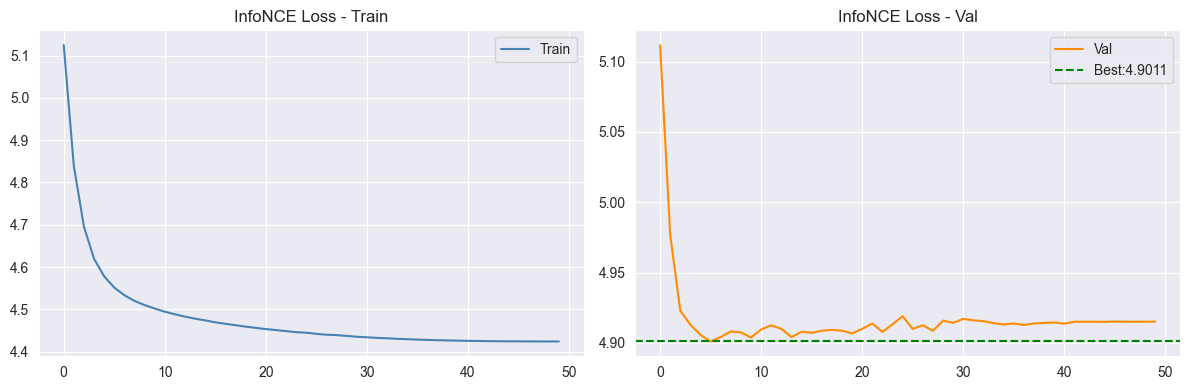

In [33]:
fig,axes=plt.subplots(1,2,figsize=(12,4))
axes[0].plot(ptl2,color='steelblue',label='Train'); axes[0].set_title('InfoNCE Loss - Train'); axes[0].legend()
axes[1].plot(pvl2,color='darkorange',label='Val'); axes[1].axhline(bpl,color='green',ls='--',label=f'Best:{bpl:.4f}')
axes[1].set_title('InfoNCE Loss - Val'); axes[1].legend()
plt.tight_layout(); plt.savefig('notebooks/Laslo/projection_loss.png',dpi=150,bbox_inches='tight'); plt.show()

## 8. Evaluare Retrieval pe Test Set
Tinte: Top-1 > 10%, Top-5 > 30%, Cosine > 0.25

In [34]:
from sklearn.metrics.pairwise import cosine_similarity
model.load_state_dict(torch.load('app/models/eegnet_model.pt',map_location=device))
proj.load_state_dict(torch.load('app/models/linear_projection.pt',map_location=device))
be=np.load('app/models/bert_embeddings.npy'); model.eval(); proj.eval()
ee_te2=get_emb(X_te)
with torch.no_grad(): prj=proj(torch.tensor(ee_te2,dtype=torch.float32).to(device)).cpu().numpy()
sims=cosine_similarity(prj,be); top5=np.argsort(sims,axis=1)[:,-5:][:,::-1]
tl2=y[tei]; tot=len(tl2)
t1=sum(top5[i,0]==w2i[tl2[i]] for i in range(tot))
t5=sum(w2i[tl2[i]] in top5[i] for i in range(tot))
mc=sims[np.arange(tot),[w2i[l] for l in tl2]].mean()
print('=== REZULTATE (InfoNCE) ===')
print(f'Top-1: {t1/tot:.3f} ({t1}/{tot})  KPI>10%: {"OK" if t1/tot>.10 else "NU"}')
print(f'Top-5: {t5/tot:.3f} ({t5}/{tot})  KPI>30%: {"OK" if t5/tot>.30 else "NU"}')
print(f'Cosine: {mc:.3f}          KPI>0.25: {"OK" if mc>.25 else "NU"}')

=== REZULTATE (InfoNCE) ===
Top-1: 0.000 (0/108)  KPI>10%: NU
Top-5: 0.000 (0/108)  KPI>30%: NU
Cosine: 0.057          KPI>0.25: NU


In [35]:
print('=== EXEMPLE ===')
for i in range(min(10,tot)):
    tw=tl2[i]; pw=[vocab_list[idx] for idx in top5[i]]
    print(f'[{"OK" if tw==pw[0] else "--"}] True:{tw:20s} Top5:{pw}')

=== EXEMPLE ===
[--] True:human                Top5:['movie', 'film', 'movies', 'one', 'films']
[--] True:times                Top5:['film', 'movie', 'movies', 'films', 'way']
[--] True:much                 Top5:['movie', 'film', 'movies', 'films', 'way']
[--] True:story                Top5:['movie', 'film', 'movies', 'films', 'good']
[--] True:much                 Top5:['film', 'movie', 'movies', 'two', 'films']
[--] True:life                 Top5:['movie', 'film', 'movies', 'films', 'way']
[--] True:human                Top5:['film', 'movie', 'films', 'movies', 'music']
[--] True:story                Top5:['film', 'movie', 'movies', 'films', 'way']
[--] True:despite              Top5:['film', 'movie', 'movies', 'films', 'way']
[--] True:life                 Top5:['movie', 'film', 'movies', 'way', 'one']


## 9. t-SNE: EEG proiectat vs. BERT

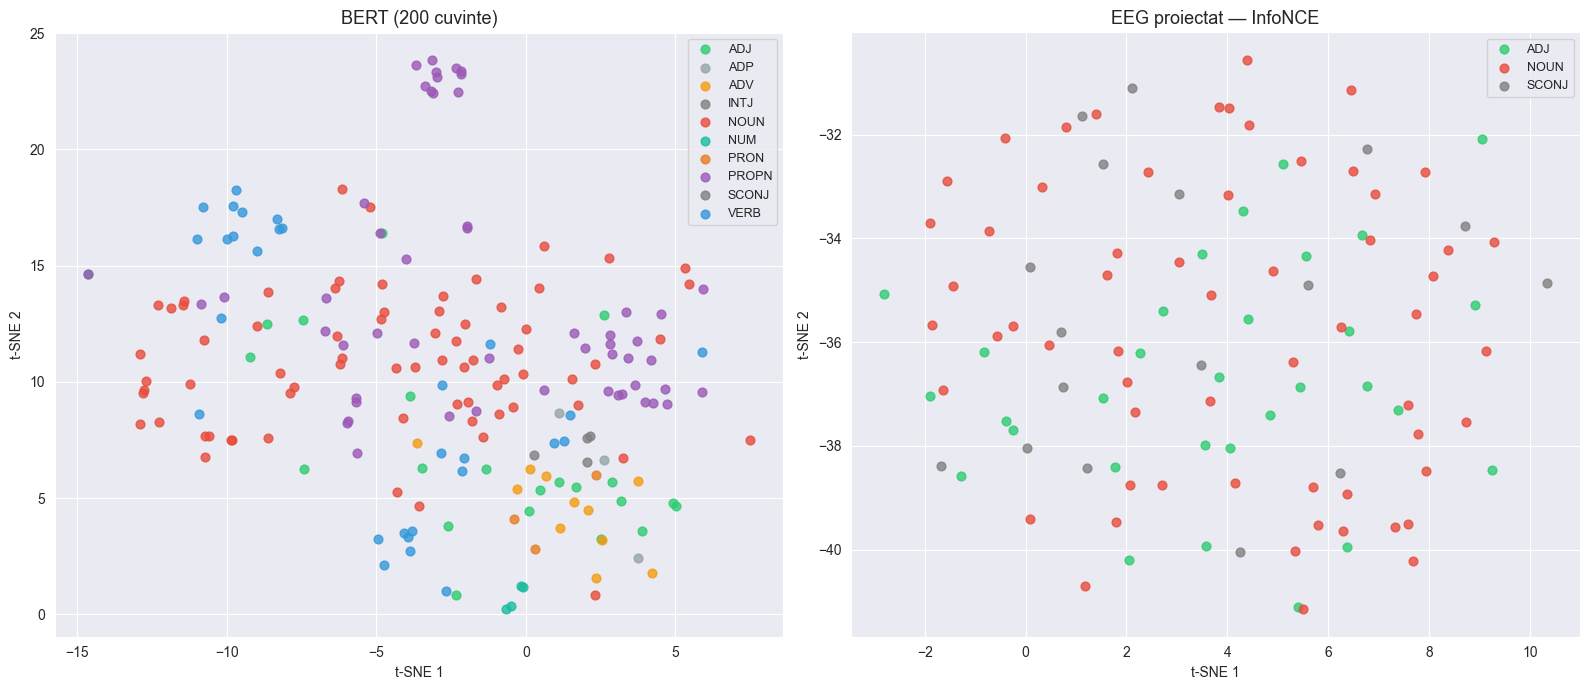

In [36]:
from sklearn.manifold import TSNE
av=np.vstack([prj,be]); a2=TSNE(n_components=2,perplexity=30,random_state=42,max_iter=1000,init='pca').fit_transform(av)
e2d=a2[:len(prj)]; b2d=a2[len(prj):]
pc={'NOUN':'#e74c3c','VERB':'#3498db','ADJ':'#2ecc71','PROPN':'#9b59b6','ADV':'#f39c12','NUM':'#1abc9c','ADP':'#95a5a6','PRON':'#e67e22'}
vpos=[pos_map.get(w,'NOUN') for w in vocab_list]; tpos=[pos_map.get(l,'NOUN') for l in tl2]
fig,axes=plt.subplots(1,2,figsize=(16,7))
for ax,vecs,poses,title in [(axes[0],b2d,vpos,'BERT (200 cuvinte)'),(axes[1],e2d,tpos,'EEG proiectat — InfoNCE')]:
    ax.set_title(title,fontsize=13)
    for pt in sorted(set(poses)):
        idx=[i for i,p in enumerate(poses) if p==pt]; ax.scatter(vecs[idx,0],vecs[idx,1],c=pc.get(pt,'gray'),label=pt,alpha=0.8,s=40)
    ax.legend(fontsize=9); ax.set_xlabel('t-SNE 1'); ax.set_ylabel('t-SNE 2')
plt.tight_layout(); plt.savefig('notebooks/Laslo/tsne_eeg_vs_bert.png',dpi=150,bbox_inches='tight'); plt.show()

## 10. Concluzii

**Pipeline final:**
EEG (5 subiecti ZuCo1 SR) -> preprocesare MNE -> EEGNet (POS proxy) -> proiectie **InfoNCE** -> retrieval cosine

**Schimbare cheie (MSE -> InfoNCE):**
- MSE: converge spre medie, Top-5 ≈ Top-1 (14.8%)
- InfoNCE: logits (B, 200), cuvantul corect vs. toate celelalte 199 simultane

**Limitari:** 5 subiecti, 85 cuvinte unice din 200 vocab.
EEG-Conformer + contrastive learning (P2 Magdas) ar imbunatati alinierea.

In [37]:
files=['app/models/eegnet_model.pt','app/models/linear_projection.pt','app/models/bert_embeddings.npy','app/models/vocab_index.json']
print('=== VERIFICARE FINALA ===')
ok=True
for fp in files:
    ex=os.path.exists(fp); sz=f'{os.path.getsize(fp)/1024:.0f}KB' if ex else 'LIPSA'
    print(f'{"OK" if ex else "XX"} {fp:45s} {sz}'); ok=ok and ex
if os.path.exists('app/models/bert_embeddings.npy'): print('  bert_emb shape:',np.load('app/models/bert_embeddings.npy').shape)
print(); print('GATA - poti face PR!' if ok else 'ATENTIE: fisiere lipsa!')

=== VERIFICARE FINALA ===
OK app/models/eegnet_model.pt                    144KB
OK app/models/linear_projection.pt               389KB
OK app/models/bert_embeddings.npy                600KB
OK app/models/vocab_index.json                   4KB
  bert_emb shape: (200, 768)

GATA - poti face PR!
